Device: cpu


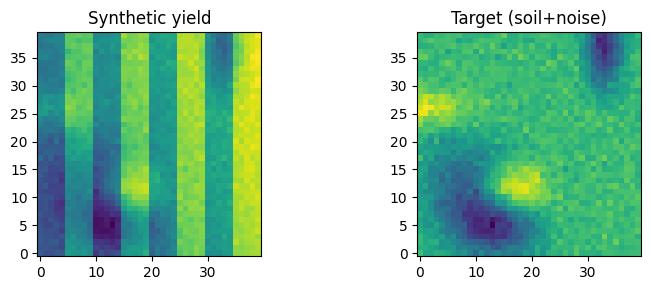

In [56]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ---------------------------
# Synthetic field generator
# ---------------------------
def make_sample(nr=40, nc=40):
    x, y = np.meshgrid(np.arange(nc), np.arange(nr))

    # smooth trend
    a_x = np.random.uniform(0.3, 0.9)
    a_y = np.random.uniform(0.1, 0.7)
    y_trend = a_x*(x/x.max()) + a_y*(y/y.max())

    # stripes (vertical bands)
    stripe_w = np.random.choice([3,4,5])
    y_stripe = ((x // stripe_w) % 2).astype(float) - 0.5

    # random gaussian soil blobs
    def gaussian_blob(cx, cy, sx, sy, amp):
        return amp*np.exp(-(((x-cx)**2)/(2*sx**2)+((y-cy)**2)/(2*sy**2)))

    n_blobs = np.random.randint(4,10)
    y_soil = np.zeros_like(x, dtype=float)
    for _ in range(n_blobs):
        cx = np.random.randint(0, nc)
        cy = np.random.randint(0, nr)
        sx = np.random.uniform(2, 7)
        sy = np.random.uniform(2, 7)
        amp = np.random.uniform(-1, 1)
        y_soil += gaussian_blob(cx, cy, sx, sy, amp)

    # noise
    y_noise = np.random.normal(0, 0.05, (nr, nc))

    # coefficients
    c0 = 2.0
    c_trend  = 0.9
    c_stripe = 0.6
    c_soil   = 0.8

    # observed yield
    yield_field = c0 + c_trend*y_trend + c_stripe*y_stripe + c_soil*y_soil + y_noise

    # "clean" target = soil + noise (what we want to keep)
    target_clean = c_soil*y_soil + y_noise

    return yield_field.astype(np.float32), target_clean.astype(np.float32)

# quick sanity check
yf, tgt = make_sample()
plt.figure(figsize=(8,3))
plt.subplot(1,2,1); plt.imshow(yf, origin='lower', cmap='viridis'); plt.title("Synthetic yield")
plt.subplot(1,2,2); plt.imshow(tgt, origin='lower', cmap='viridis'); plt.title("Target (soil+noise)")
plt.tight_layout(); plt.show()


In [57]:
class YieldDataset(Dataset):
    def __init__(self, n_samples=2000, nr=40, nc=40):
        self.n_samples = n_samples
        self.nr = nr
        self.nc = nc

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        yf, tgt = make_sample(self.nr, self.nc)
        # add channel dimension for CNN: (1, H, W)
        return (
            torch.from_numpy(yf[None, :, :]),
            torch.from_numpy(tgt[None, :, :])
        )

train_ds = YieldDataset(n_samples=2000)
val_ds   = YieldDataset(n_samples=200)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False)


In [11]:
class DetrendCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(8, 8, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(8, 1, kernel_size=3, padding=1)
        )

    def forward(self, x):
        correction = self.net(x)      # Δ(x)
        out = x - correction          # remove learned pattern
        return out, correction

model = DetrendCNN().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


In [13]:
class DetrendCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, padding=1),
            nn.GELU(),                       # <-- ReLU replaced with GELU

            nn.Conv2d(8, 8, kernel_size=3, padding=1),
            nn.GELU(),                       # <-- ReLU replaced with GELU

            nn.Conv2d(8, 1, kernel_size=3, padding=1)
            # (no activation on last layer; we want correction Δ to be linear)
        )

    def forward(self, x):
        correction = self.net(x)     # Δ(x)
        out = x - correction         # subtract learned pattern
        return out, correction

model = DetrendCNN().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


In [17]:
class DetrendCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(

            # Layer 1
            nn.Conv2d(1, 8, kernel_size=3, padding=1),
            nn.GELU(),

            # Layer 2
            nn.Conv2d(8, 8, kernel_size=3, padding=1),
            nn.GELU(),

            # ⭐ New Layer 3 (ADDED)
            nn.Conv2d(8, 8, kernel_size=3, padding=1),
            nn.GELU(),

            # Final Layer (correction output)
            nn.Conv2d(8, 1, kernel_size=3, padding=1)
        )

    def forward(self, x):
        correction = self.net(x)  # Δ(x)
        out = x - correction      # residual learning
        return out, correction
model = DetrendCNN().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [38]:
class HybridActivationCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(

            # Layer 1 — GELU (smooth, blob-friendly)
            nn.Conv2d(1, 8, kernel_size=3, padding=1),
            nn.GELU(),

            # Layer 2 — GELU (trend & smooth background modeling)
            nn.Conv2d(8, 8, kernel_size=3, padding=1),
            nn.GELU(),

            # Layer 3 — LeakyReLU (stripe/edge orientation)
            nn.Conv2d(8, 8, kernel_size=3, padding=1),
            nn.LeakyReLU(0.1, inplace=True),

            # Layer 4 — LeakyReLU (stronger directional detection)
            nn.Conv2d(8, 8, kernel_size=3, padding=1),
            nn.LeakyReLU(0.1, inplace=True),

            # Final correction layer
            nn.Conv2d(8, 1, kernel_size=3, padding=1)
        )

    def forward(self, x):
        correction = self.net(x)      # learned Δ(x)
        cleaned = x - correction       # residual learning
        return cleaned, correction

model = HybridActivationCNN().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


In [58]:
class MultiScaleConv(nn.Module):
    def __init__(self, in_channels=1, out_channels=8):
        super().__init__()

        # Branch 1: fine 3x3 conv
        self.conv3 = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.GELU()
        )

        # Branch 2: medium 5x5 conv
        self.conv5 = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=5, padding=2),
            nn.GELU()
        )

        # Branch 3: coarse 7x7 conv
        self.conv7 = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=7, padding=3),
            nn.GELU()
        )

        # Fuse channels
        self.fuse = nn.Sequential(
            nn.Conv2d(out_channels * 3, out_channels, kernel_size=1),
            nn.GELU()
        )

    def forward(self, x):
        b3 = self.conv3(x)
        b5 = self.conv5(x)
        b7 = self.conv7(x)

        merged = torch.cat([b3, b5, b7], dim=1)
        return self.fuse(merged)

#model = MultiScaleConv().to(device)
#criterion = nn.MSELoss()
#optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [59]:
class MultiScaleDetrendCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.ms1 = MultiScaleConv(1, 8)
        self.ms2 = MultiScaleConv(8, 8)
        self.ms3 = MultiScaleConv(8, 8)

        self.final = nn.Conv2d(8, 1, kernel_size=3, padding=1)

    def forward(self, x):
        out = self.ms1(x)
        out = self.ms2(out)
        out = self.ms3(out)

        correction = self.final(out)         # Δ(x)
        cleaned = x - correction             # subtract learned trend+stripes

        return cleaned, correction
model = MultiScaleDetrendCNN().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [63]:
def run_epoch(loader, train=True):
    if train:
        model.train()
    else:
        model.eval()
    total_loss = 0.0
    with torch.set_grad_enabled(train):
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)
            y_hat, corr = model(x)
            loss = criterion(y_hat, y)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item()*x.size(0)
    return total_loss / len(loader.dataset)

n_epochs = 30
for epoch in range(1, n_epochs+1):
    train_loss = run_epoch(train_loader, train=True)
    val_loss   = run_epoch(val_loader, train=False)
    print(f"Epoch {epoch:02d}  train MSE={train_loss:.5f}  val MSE={val_loss:.5f}")


Epoch 01  train MSE=0.03032  val MSE=0.03115
Epoch 02  train MSE=0.03098  val MSE=0.03554
Epoch 03  train MSE=0.02949  val MSE=0.02995
Epoch 04  train MSE=0.02963  val MSE=0.02965
Epoch 05  train MSE=0.02891  val MSE=0.03317
Epoch 06  train MSE=0.02863  val MSE=0.02407
Epoch 07  train MSE=0.02505  val MSE=0.02383
Epoch 08  train MSE=0.02426  val MSE=0.02475
Epoch 09  train MSE=0.02523  val MSE=0.02314
Epoch 10  train MSE=0.02133  val MSE=0.01974
Epoch 11  train MSE=0.02290  val MSE=0.02124
Epoch 12  train MSE=0.02068  val MSE=0.02312
Epoch 13  train MSE=0.02158  val MSE=0.01728
Epoch 14  train MSE=0.02020  val MSE=0.01934
Epoch 15  train MSE=0.01967  val MSE=0.01910
Epoch 16  train MSE=0.02146  val MSE=0.02140
Epoch 17  train MSE=0.02051  val MSE=0.01845
Epoch 18  train MSE=0.01906  val MSE=0.02019
Epoch 19  train MSE=0.01877  val MSE=0.01900
Epoch 20  train MSE=0.02085  val MSE=0.02232
Epoch 21  train MSE=0.01778  val MSE=0.02240
Epoch 22  train MSE=0.01884  val MSE=0.01755
Epoch 23  

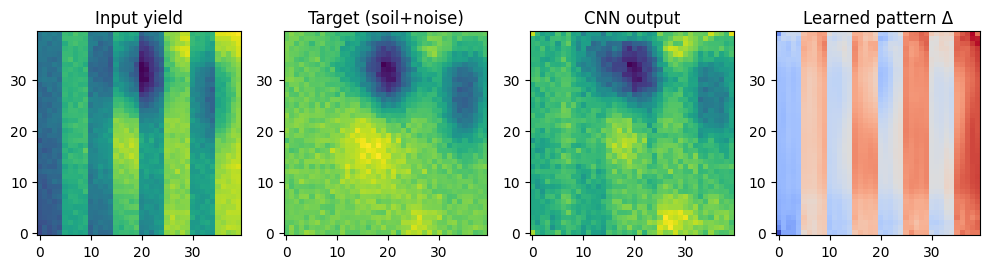

In [68]:
model.eval()
with torch.no_grad():
    yf, tgt = make_sample()
    x = torch.from_numpy(yf[None,None,:,:]).to(device)   # (1,1,H,W)
    y_true = torch.from_numpy(tgt[None,None,:,:]).to(device)
    y_hat, corr = model(x)

yf_pred   = y_hat[0,0].cpu().numpy()
corr_pred = corr[0,0].cpu().numpy()

plt.figure(figsize=(10,3))
plt.subplot(1,4,1); plt.imshow(yf, origin='lower', cmap='viridis'); plt.title("Input yield")
plt.subplot(1,4,2); plt.imshow(tgt, origin='lower', cmap='viridis'); plt.title("Target (soil+noise)")
plt.subplot(1,4,3); plt.imshow(yf_pred, origin='lower', cmap='viridis'); plt.title("CNN output")
plt.subplot(1,4,4); plt.imshow(corr_pred, origin='lower', cmap='coolwarm'); plt.title("Learned pattern Δ")
plt.tight_layout(); plt.show()


In [55]:
# classic stencils for reference
rook_kernel = np.array([[0,1,0],
                        [1,-4,1],
                        [0,1,0]], dtype=np.float32)

laplace_8 = np.array([[1,1,1],
                      [1,-8,1],
                      [1,1,1]], dtype=np.float32)

# get first layer weights
first_conv = model.net[0]
weights = first_conv.weight.data.cpu().numpy()   # shape (out_channels, in_channels, 3,3)

n_filters = weights.shape[0]
plt.figure(figsize=(3*n_filters, 3))
for i in range(n_filters):
    k = weights[i,0]
    plt.subplot(1, n_filters, i+1)
    plt.imshow(k, cmap='coolwarm')
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.title(f"Filter {i}")
    plt.axis('off')
plt.suptitle("Learned first-layer kernels", y=1.05)
plt.tight_layout()
plt.show()

print("Rook-like kernel:\n", rook_kernel)
print("8-neighbor Laplacian:\n", laplace_8)


AttributeError: 'MultiScaleDetrendCNN' object has no attribute 'net'